In [ ]:
import polars as pl
df = pl.read_parquet("..\data\dblp_parquet\dblp_data_2015_plus.parquet")

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\micha\AppData\Local\Temp\ipykernel_25728\3242421162.py:2: SyntaxWarning: invalid escape sequence '\d'
  df = pl.read_parquet("data\dblp_parquet\dblp_data_2015_plus.parquet")


FileNotFoundError: System nie może odnaleźć określonej ścieżki. (os error 3): data/dblp_parquet/dblp_data_2015_plus.parquet

In [ ]:
df.sample(5)

key,type,title,year,venue,authors
str,str,str,i32,str,list[str]
"""journals/joi/MeierCLL23""","""article""","""Co-patents in Europe: Methodol…",2023,"""J. Informetrics""","[""Max Meier"", ""Julie Callaert"", … ""Bart Van Looy""]"
"""conf/mass/MighanMM25""","""inproceedings""","""A Dual-Layer Blockchain Shardi…",2025,"""MASS""","[""Sima Naderi Mighan"", ""Jelena V. Misic"", ""Vojislav B. Misic""]"
"""journals/jolis/Oppenheim21""","""article""","""Book review: Richard Ovenden, """,2021,"""J. Libr. Inf. Sci.""","[""Charles Oppenheim""]"
"""conf/icc/BoscaroMCZ25""","""inproceedings""","""To Train or Not to Train: Bala…",2025,"""ICC""","[""Maddalena Boscaro"", ""Federico Mason"", … ""Andrea Zanella""]"
"""conf/emnlp/ZhangYFLSLMZWS24""","""inproceedings""","""Multi-Level Cross-Modal Alignm…",2024,"""EMNLP""","[""Liang Zhang"", ""Zhen Yang"", … ""Jinsong Su""]"


In [ ]:
print(df['venue'].unique())

shape: (11_669,)
Series: 'venue' [str]
[
	"IEEE Trans. Circuits Syst. II …
	"IEEE Trans. Comput. Biol. Bioi…
	"Gender and Diversity Policy in…
	"JURSE"
	"DASC"
	…
	"Recent Advances in Computer Vi…
	"Int. J. Metadata Semant. Ontol…
	"ACM SIGACCESS Access. Comput."
	"POPL"
	"SUMob@SIGSPATIAL"
]


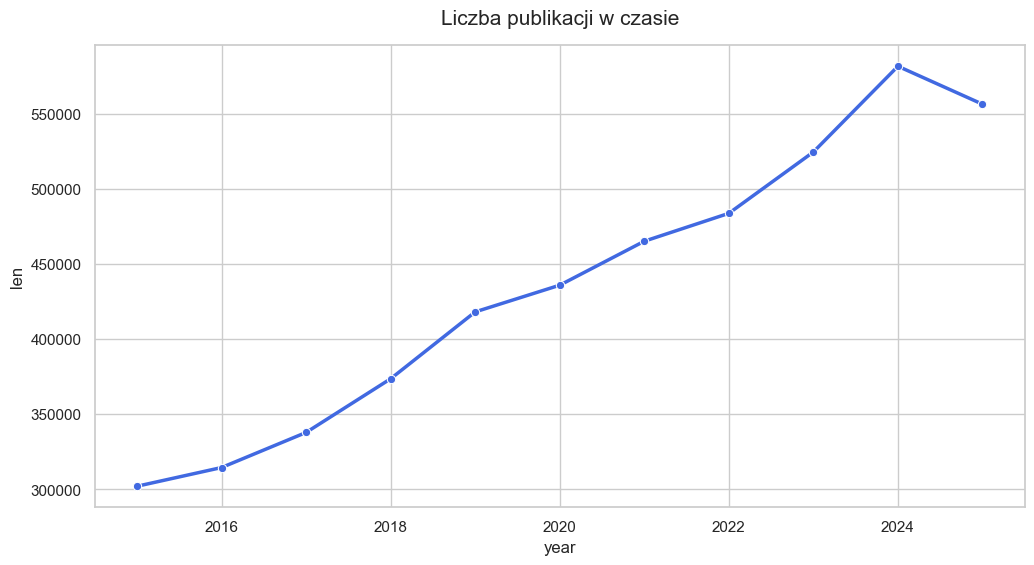

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

start_year = 2015
end_year = 2025

yearly_counts = (
    df.filter(
        (pl.col("year") >= start_year) & (pl.col("year") <= end_year)
    )
    .group_by("year")
    .len()              
    .sort("year")      
)

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

plot = sns.lineplot(
    data=yearly_counts.to_pandas(), 
    x='year', 
    y='len', 
    marker='o', 
    color='royalblue', 
    linewidth=2.5
)

plt.show()

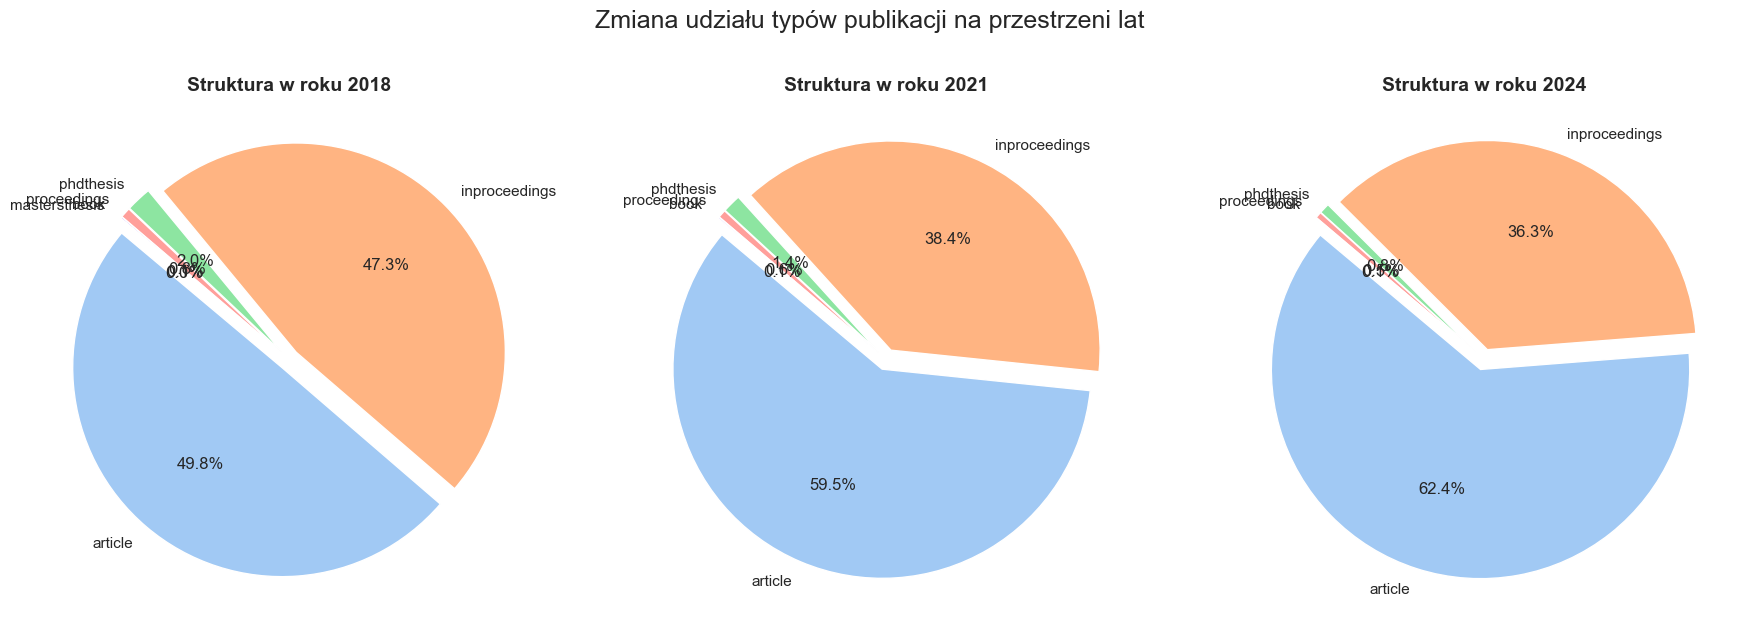

In [ ]:


years_to_show = [2018, 2021, 2024]
n_years = len(years_to_show)

sns.set_theme(style="white")
colors = sns.color_palette("pastel") 

fig, axes = plt.subplots(1, n_years, figsize=(18, 6))

for i, year in enumerate(years_to_show):
    res = (
        df.filter(pl.col("year") == year)
        .group_by("type")
        .len()
        .sort("len", descending=True)
    )
    
    axes[i].pie(
        res["len"].to_list(), 
        labels=res["type"].to_list(), 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors,
        explode=[0.05] * res.height
    )
    axes[i].set_title(f"{year}", fontsize=14, fontweight='bold')


plt.tight_layout()
plt.show()

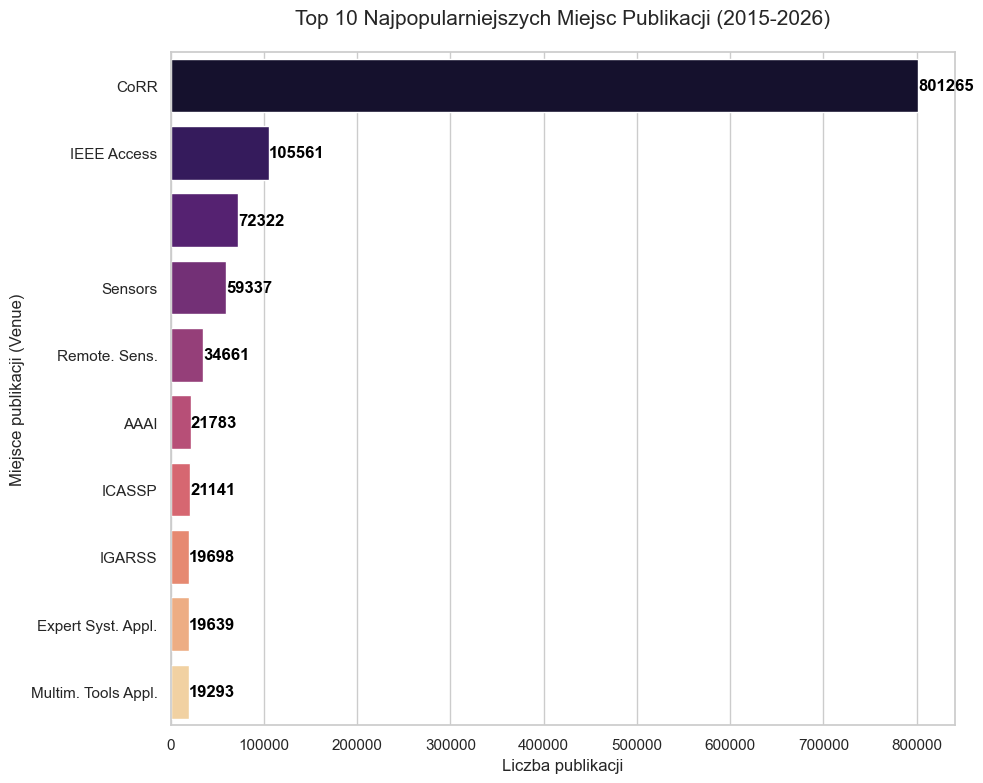

In [ ]:

top_venues = (
    df.group_by("venue")
    .len()
    .rename({"len": "count"})
    .sort("count", descending=True)
    .head(10)
)


sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 8))

plot = sns.barplot(
    data=top_venues.to_pandas(), 
    x='count', 
    y='venue', 
    palette="magma", 
    hue='venue', 
    legend=False
)


plt.tight_layout()
plt.show()

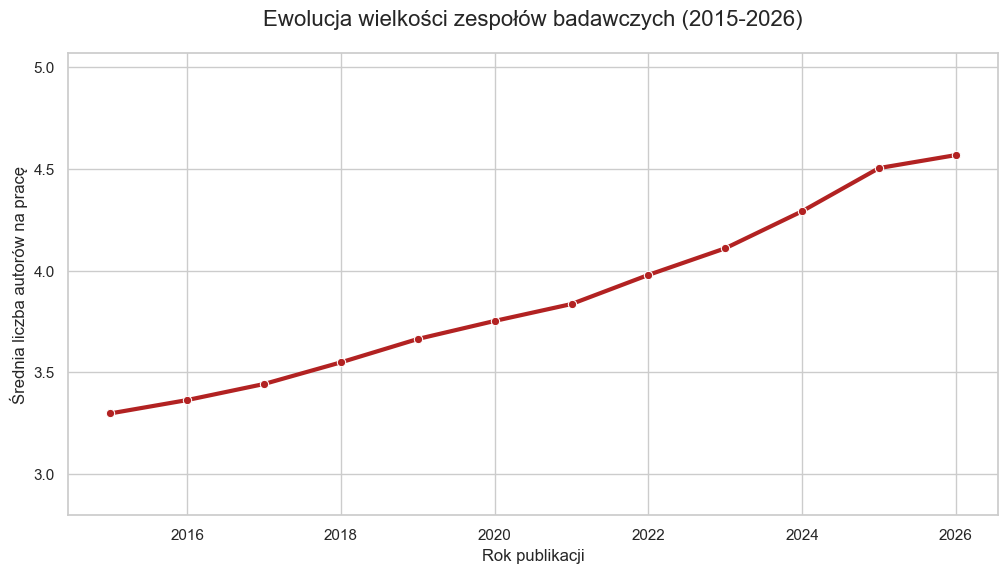

In [ ]:

df = df.with_columns(
    author_count = pl.col("authors").list.len()
)
team_trends = (
    df.group_by("year")
    .agg(
        pl.col("author_count").mean().alias("avg_author_count")
    )
    .sort("year")
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

plot_df = team_trends.to_pandas()

plot = sns.lineplot(
    data=plot_df, 
    x='year', 
    y='avg_author_count', 
    marker='o', 
    color='firebrick', 
    linewidth=3
)


plt.ylim(
    plot_df['avg_author_count'].min() - 0.5, 
    plot_df['avg_author_count'].max() + 0.5
)

plt.show()